In [ ]:
!pip install torch torchvision matplotlib opencv-python pillow

In [ ]:
import torch
import torchvision
from torchvision import transforms
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [ ]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
model.eval()

print("Model loaded successfully!")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 147MB/s]


Model loaded successfully!


In [ ]:
from google.colab import files

# The file '/content/IMG_9293.jpeg' is already available in the kernel.
# You can load it directly using PIL (Pillow).
# from google.colab import files is not needed here if you only want to load an existing file.
image_path = '/content/IMG_9293.jpeg'
image = Image.open(image_path)
print(f"Image loaded successfully from {image_path}")

Image loaded successfully from /content/IMG_9293.jpeg


In [ ]:
# read image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# transform
transform = transforms.Compose([
    transforms.ToTensor()
])

input_tensor = transform(image)
input_tensor = input_tensor.unsqueeze(0)

In [ ]:
with torch.no_grad():
    outputs = model(input_tensor)

print("Detection completed!")

Detection completed!


In [ ]:
boxes = outputs[0]['boxes']
scores = outputs[0]['scores']
labels = outputs[0]['labels']

print("Top 5 Bounding Boxes:\n", boxes[:5])
print("\nTop 5 Confidence Scores:\n", scores[:5])
print("\nTop 5 Labels:\n", labels[:5])

Top 5 Bounding Boxes:
 tensor([[ 368.2408,  618.8250, 3354.3596, 5590.6470],
        [3455.1863, 1753.6902, 4283.2358, 5712.0000],
        [3017.9119,  583.0739, 3803.8777, 1918.2866],
        [  26.0045,    9.0475,  763.4420, 2353.6279],
        [3582.0815,  353.9014, 4268.2275, 2028.4163]])

Top 5 Confidence Scores:
 tensor([0.9984, 0.9876, 0.9496, 0.9141, 0.8239])

Top 5 Labels:
 tensor([ 1,  1, 27,  1,  1])


(np.float64(-0.5), np.float64(4283.5), np.float64(5711.5), np.float64(-0.5))

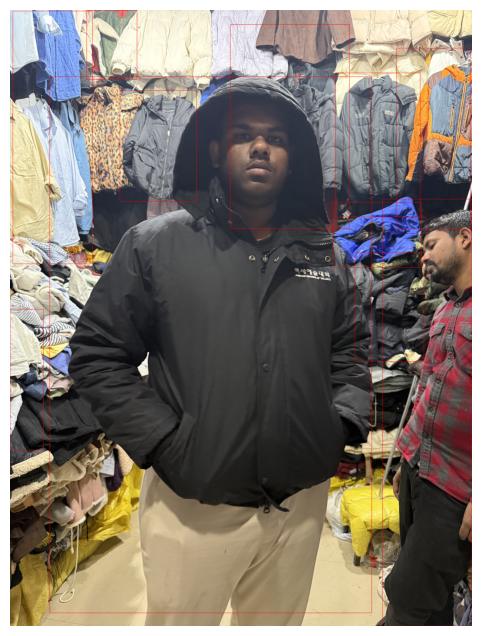

In [ ]:
threshold = 0.5
image_copy = image.copy()

for i in range(len(boxes)):
    if scores[i] > threshold:
        box = boxes[i].numpy().astype(int)
        cv2.rectangle(image_copy,
                      (box[0], box[1]),
                      (box[2], box[3]),
                      (255, 0, 0),
                      2)

plt.figure(figsize=(8,8))
plt.imshow(image_copy)
plt.axis('off')